# 02 · Entrenamiento (YOLOv8n) y evaluación offline

Lanza `src/train.py` (opcional) y analiza sus artefactos: `models/model_metadata.json`, `reports/offline/metrics.json`,
curvas de entrenamiento y matriz de confusión / curva PR.

> El entrenamiento real requiere `ultralytics` y, idealmente, GPU. Pon `RUN_TRAIN = True` sólo cuando quieras entrenar desde aquí.

In [1]:
import sys
from pathlib import Path

_nb = Path.cwd() if (Path.cwd() / "helpers.py").exists() else Path.cwd() / "notebooks"
sys.path.insert(0, str(_nb))
from helpers import *   # utilidades compartidas (pd, plt, np, run, read_json, show_images...)

REPO = setup()          # cambia el directorio de trabajo a la raíz del repo
print("Repositorio:", REPO)

Repositorio: /home/usuario/Code/Projects/Computer Vision Projects/PPE-detection-using-computer-vision


In [2]:
MODELS_DIR  = env("MODELS_DIR", "models")
OFFLINE_DIR = env("OFFLINE_DIR", "reports/offline")
RUN_TRAIN   = False                         # True: entrena desde este notebook
TRAIN_OVERRIDES = []                        # p. ej. ["train.epochs=2", "train.batch=8"] para una prueba rápida

In [3]:
if RUN_TRAIN:
    run([sys.executable, "src/train.py", "--config", "configs/train.yaml", "--set", *TRAIN_OVERRIDES], tail=25)
meta_path = Path(MODELS_DIR) / "model_metadata.json"
meta = read_json(meta_path) if exists_or_hint(meta_path, "Ejecuta src/train.py (RUN_TRAIN = True).") else None

## 1. Configuración y trazabilidad del entrenamiento

In [4]:
if meta:
    t = meta["training"]
    cfg_table = pd.Series({
        "Arquitectura": meta["architecture"], "Pesos iniciales": meta["initial_weights"],
        "Versión del modelo": meta["model_version"], "Tamaño de entrada": t["imgsz"],
        "Épocas (pedidas / completadas)": f'{meta["epochs_requested"]} / {meta["epochs_completed"]}',
        "Batch": t["batch"], "Optimizador": t["optimizer"], "LR inicial / final (lrf)": f'{t["lr0"]} / {t["lrf"]}',
        "Semilla / determinista": f'{t["seed"]} / {t["deterministic"]}',
        "Duración (s)": t["duration_seconds"], "Mejor fitness": round(meta["best_fitness"], 4),
        "Hardware": meta["hardware"].get("gpu") or meta["hardware"]["platform"],
        "Ultralytics / Torch": f'{meta["hardware"].get("ultralytics")} / {meta["hardware"].get("torch")}',
        "Huella del dataset (sha256)": meta["dataset"]["fingerprint"]["sha256"][:16] + "…",
        "Imágenes por partición": meta["dataset"]["fingerprint"]["images_per_split"],
        "Criterio del mejor checkpoint": meta["best_checkpoint_criterion"]}, name="valor")
    display(cfg_table.to_frame())
    print("Aumentos:", meta["augmentations"])

,valor
Arquitectura,yolov8n
Pesos iniciales,yolov8n.pt
Versión del modelo,1.0.0
Tamaño de entrada,640
Épocas (pedidas / completadas),20 / 20
Batch,8
Optimizador,AdamW
LR inicial / final (lrf),0.001 / 0.01
Semilla / determinista,42 / True
Duración (s),3494.5


Aumentos: {'hsv_h': 0.015, 'hsv_s': 0.7, 'hsv_v': 0.4, 'degrees': 0.0, 'translate': 0.1, 'scale': 0.5, 'shear': 0.0, 'flipud': 0.0, 'fliplr': 0.5, 'mosaic': 1.0, 'mixup': 0.0, 'close_mosaic': 10}


## 2. Curvas de entrenamiento

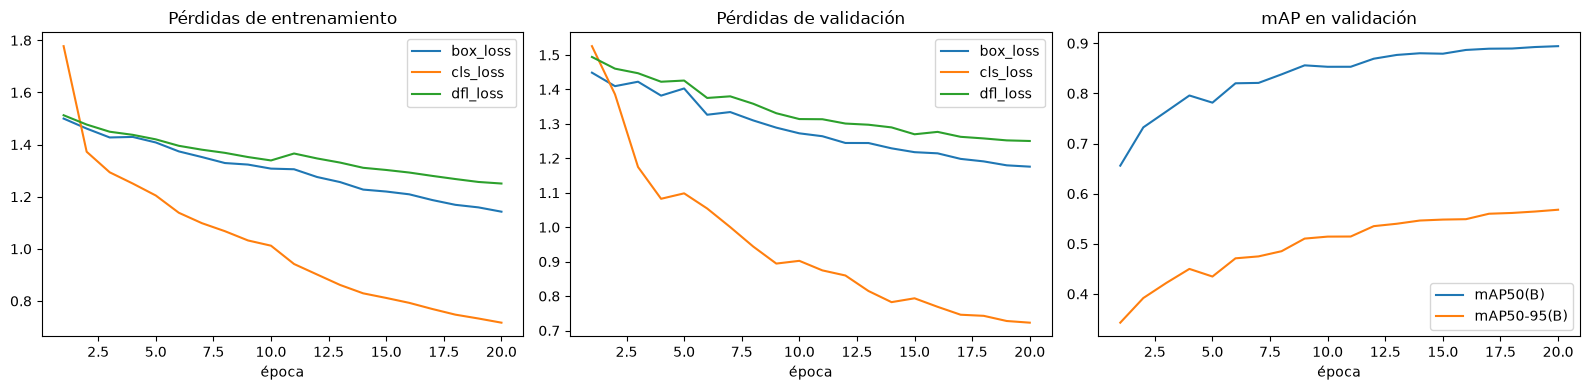

Época con mejor mAP@0.5:0.95: 19


In [5]:
if meta:
    csv = Path(meta["run_dir"]) / "results.csv"
    if exists_or_hint(csv, "Ultralytics guarda results.csv en la carpeta de la corrida."):
        res = pd.read_csv(csv)
        res.columns = [c.strip() for c in res.columns]
        fig, ax = plt.subplots(1, 3, figsize=(16, 4))
        for c in [c for c in res.columns if c.startswith("train/") and c.endswith("_loss")]:
            ax[0].plot(res["epoch"], res[c], label=c.replace("train/", ""))
        ax[0].set(title="Pérdidas de entrenamiento", xlabel="época"); ax[0].legend()
        for c in [c for c in res.columns if c.startswith("val/") and c.endswith("_loss")]:
            ax[1].plot(res["epoch"], res[c], label=c.replace("val/", ""))
        ax[1].set(title="Pérdidas de validación", xlabel="época"); ax[1].legend()
        for c in [c for c in res.columns if c.startswith("metrics/mAP")]:
            ax[2].plot(res["epoch"], res[c], label=c.replace("metrics/", ""))
        ax[2].set(title="mAP en validación", xlabel="época"); ax[2].legend()
        plt.tight_layout(); plt.show()
        best_epoch = int(res["metrics/mAP50-95(B)"].idxmax()) if "metrics/mAP50-95(B)" in res else None
        print("Época con mejor mAP@0.5:0.95:", best_epoch)

## 3. Métricas offline por partición y por clase

In [6]:
metrics_path = Path(OFFLINE_DIR) / "metrics.json"
metrics = read_json(metrics_path) if exists_or_hint(metrics_path, "Se genera al final de src/train.py.") else None
if metrics:
    glob = pd.DataFrame({s: m["global"] for s, m in metrics["splits"].items()}).T
    display(glob)
    for s, m in metrics["splits"].items():
        print(f"\n--- {s}: por clase ---")
        display(pd.DataFrame(m["per_class"]).T)

[falta] reports/offline/metrics.json
        -> Se genera al final de src/train.py.


## 4. Velocidad de inferencia

In [7]:
if metrics:
    speed = pd.DataFrame({s: {"ms/imagen (inferencia)": m.get("avg_inference_ms"),
                              "FPS (sólo inferencia)": m.get("fps_inference_only"),
                              "FPS (extremo a extremo, lote)": m.get("fps_end_to_end_batch"),
                              **{f"{k} (ms)": v for k, v in m["speed_ms_per_image"].items()}}
                          for s, m in metrics["splits"].items()}).T
    display(speed)

## 5. Matriz de confusión y curva Precision–Recall

In [8]:
show_images([Path(OFFLINE_DIR) / "confusion_matrix.png", Path(OFFLINE_DIR) / "precision_recall_curve.png"],
            cols=2, size=(7.5, 6))

No hay imágenes para mostrar todavía.


## 6. Interpretación (completar para el reporte, secciones 3 y 4)

| Pregunta | Respuesta |
|---|---|
| ¿Qué clases tienen menor AP y por qué? | _<>_ |
| ¿Hay sobreajuste (val vs test)? | _<>_ |
| ¿El mejor checkpoint está cerca de la última época? ¿Falta entrenar? | _<>_ |
| ¿Cumple el FPS requerido en el hardware objetivo? | _<>_ |